## A/B Testing - Probabilistic Price Experiment

**Input:** 
- data/ventas_clean.csv 
- data/rfm_segments.csv  

**Business question:** The price elasticity analysis found inelastic demand.  
That means a price increse should increase revenue in aggregate.  
But which customer segments benefit? Which are at risk? With how much confidence?



# Setup

In [10]:
import os
import pathlib
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

ROOT = pathlib.Path().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)

np.random.seed(42)
N_SIM = 20_000  

C = dict(
    bg='#0A0E17', surface='#111827', surf2='#1A2235',
    border='#1E2D45', accent='#00E5A0', gold='#F5C842',
    red='#FF4D6A', blue='#4D9FFF', orange='#E8883A',
    purple='#A78BFA', text='#E8EDF5', muted='#6B7A99',
)

mpl.rcParams.update({
    'figure.facecolor': C['bg'], 'axes.facecolor': C['surface'],
    'axes.edgecolor': C['border'], 'axes.labelcolor': C['muted'],
    'axes.titlecolor': C['text'], 'text.color': C['text'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': C['border'], 'grid.linewidth': 0.6,
    'xtick.color': C['muted'], 'ytick.color': C['muted'],
    'font.family': 'DejaVu Sans',
})

os.makedirs(ROOT / 'plots', exist_ok=True)

df  = pd.read_csv(ROOT / 'data' / 'ventas_clean.csv', parse_dates=['date'])
rfm = pd.read_csv(ROOT / 'data' / 'rfm_segments.csv')

print(f'Orders loaded: {len(df):,}')
print(f'RFM segments: {len(rfm):,} SKUs')
print(f'Segments found: {rfm["segment"].unique()}')
print(f'Monte Carlo N: {N_SIM:,}')

Orders loaded: 353
RFM segments: 120 SKUs
Segments found: ['Loyal' 'Lost' 'Potential' 'VIP' 'Occasional' 'At Risk']
Monte Carlo N: 20,000


## Classical vs Bayesian 

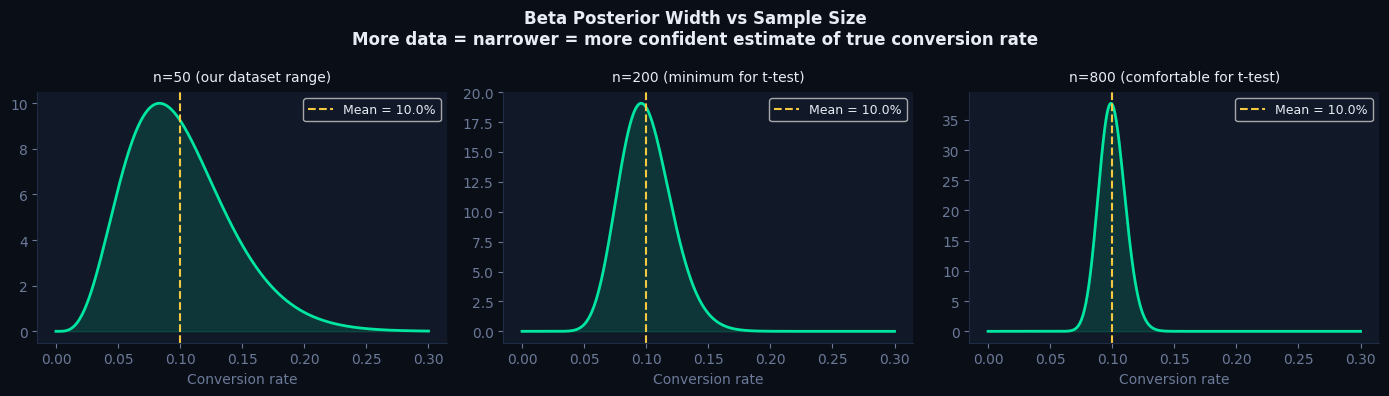

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), facecolor=C['bg'])
fig.suptitle('Beta Posterior Width vs Sample Size\n'
             'More data = narrower = more confident estimate of true conversion rate',
             fontsize=12, fontweight='bold', color=C['text'])

scenarios = [
    (5, 45, 'n=50 (our dataset range)'),
    (20, 180, 'n=200 (minimum for t-test)'),
    (80, 720, 'n=800 (comfortable for t-test)'),
]

x = np.linspace(0, 0.3, 500)
for ax, (a, b, label) in zip(axes, scenarios):
    y = stats.beta.pdf(x, a, b)
    ax.plot(x, y, color=C['accent'], linewidth=2)
    ax.fill_between(x, y, alpha=0.15, color=C['accent'])
    ax.axvline(a/(a+b), color=C['gold'], linewidth=1.5, linestyle='--',
               label=f'Mean = {a/(a+b):.1%}')
    ax.set_title(label, fontsize=10, pad=8)
    ax.set_xlabel('Conversion rate')
    ax.legend(fontsize=9)
    ax.set_facecolor(C['surface'])
    for sp in ['top','right']:
        ax.spines[sp].set_visible(False)
    for sp in ['left','bottom']:
        ax.spines[sp].set_color(C['border'])

plt.tight_layout()
plt.savefig(ROOT / 'plots' / '24_beta_posteriors.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

## Segment Profiles

In [12]:
monthly = (
    df.groupby(df['date'].dt.to_period('M'))
    .agg(quantity=('order_id','count'), price_real=('unit_price_real','median'))
    .reset_index()
    .dropna()
)
monthly = monthly[monthly['quantity'] > 0]
agg_elasticity, _, _, _, _ = stats.linregress(
    np.log(monthly['price_real']), np.log(monthly['quantity'])
)
print(f'Aggregate elasticity (reproduced): {agg_elasticity:.4f}')

# Segment profiles
ELASTICITY_MULTIPLIER = {
    'VIP': 0.45,
    'Loyal': 0.60,
    'Potential': 1.00,  
    'At Risk': 1.35,
    'Occasional': 1.20,
    'Lost': 1.50,
}

seg_stats = (
    df.groupby(df['date'].dt.year)
    .agg(orders=('order_id','count'), revenue=('gross_revenue_real','sum'))
    .reset_index()
)
monthly_orders = seg_stats['orders'].sum() / (df['date'].dt.to_period('M').nunique())

segments = []
for seg, row in rfm.groupby('segment').agg(
    n = ('sku_id', 'count'),
    avg_ticket = ('total_spend', 'mean'),
    total_rev = ('total_spend', 'sum'),
).iterrows():
    rev_share = row['total_rev'] / rfm['total_spend'].sum()
    conv_rate = row['n'] / (row['n'] + 50)
    elasticity_seg = agg_elasticity * ELASTICITY_MULTIPLIER.get(seg, 1.0)
    segments.append({
        'segment': seg,
        'n_skus': int(row['n']),
        'avg_ticket': row['avg_ticket'],
        'revenue_share': rev_share,
        'conv_rate': conv_rate,
        'elasticity': elasticity_seg,
        'elasticity_mult': ELASTICITY_MULTIPLIER.get(seg, 1.0),
    })

seg_df = pd.DataFrame(segments).sort_values('revenue_share', ascending=False)

print(f'\n{"Segment":<12} {"n SKUs":>7} {"Rev share":>10} {"Avg ticket":>12} {"Elasticity":>12} {"Note"}')
print()
for _, r in seg_df.iterrows():
    note = f'x{r["elasticity_mult"]:.2f} agg'
    print(f'{r["segment"]:<12} {r["n_skus"]:>7} {r["revenue_share"]:>9.1%} '
          f'${r["avg_ticket"]:>10,.0f} {r["elasticity"]:>12.3f}  {note}')


Aggregate elasticity (reproduced): -0.6539

Segment       n SKUs  Rev share   Avg ticket   Elasticity Note

VIP               17     49.6% $    45,658       -0.294  x0.45 agg
Loyal             29     30.5% $    16,454       -0.392  x0.60 agg
Potential         14      7.7% $     8,561       -0.654  x1.00 agg
At Risk           19      6.3% $     5,177       -0.883  x1.35 agg
Occasional        19      3.7% $     3,038       -0.785  x1.20 agg
Lost              22      2.2% $     1,598       -0.981  x1.50 agg


## Monte Carlo Simulation

In [13]:
PRICE_INCREASE = 0.10  

def simulate_segment(seg_row, price_increase, n_sim, n_visitors=200):
    # Beta posterior parameters
    alpha_ctrl = max(seg_row['n_skus'], 1)
    beta_ctrl = max(n_visitors - seg_row['n_skus'], 1)

    p_ctrl = np.random.beta(alpha_ctrl, beta_ctrl, n_sim)

    # Treatment demand response 
    demand_multiplier = (1 + price_increase) ** seg_row['elasticity']
    p_treat = np.clip(p_ctrl * demand_multiplier, 0, 1)

    # Sample orders under each condition
    orders_ctrl = np.random.binomial(n_visitors, p_ctrl)
    orders_treat = np.random.binomial(n_visitors, p_treat)

    # Revenue: treatment group pays the higher price
    rev_ctrl = orders_ctrl * seg_row['avg_ticket']
    rev_treat = orders_treat * seg_row['avg_ticket'] * (1 + price_increase)

    p_win = (rev_treat > rev_ctrl).mean()
    exp_lift = (rev_treat - rev_ctrl).mean()
    lift_p5 = np.percentile(rev_treat - rev_ctrl, 5)
    lift_p95 = np.percentile(rev_treat - rev_ctrl, 95)

    return {
        'segment': seg_row['segment'],
        'p_win': p_win,
        'exp_lift': exp_lift,
        'lift_p5': lift_p5,
        'lift_p95': lift_p95,
        'verdict': 'IMPLEMENT' if p_win >= 0.80 else 'RUN TEST' if p_win >= 0.60 else 'DO NOT IMPLEMENT',
        'rev_ctrl': rev_ctrl,
        'rev_treat': rev_treat,
    }

results = [simulate_segment(row, PRICE_INCREASE, N_SIM) for _, row in seg_df.iterrows()]
res_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['rev_ctrl','rev_treat']} for r in results])

print(f'Simulation: +{PRICE_INCREASE*100:.0f}% price increase | {N_SIM:,} Monte Carlo draws per segment')
print()
print(f'{"Segment":<12} {"P(win)":>8} {"E[Lift]":>12} {"90% CI":>28} {"Verdict"}')
print()
for r in results:
    print(f'{r["segment"]:<12} {r["p_win"]:>7.1%} '
          f'${r["exp_lift"]:>10,.0f} '
          f'[${r["lift_p5"]:>10,.0f}, ${r["lift_p95"]:>10,.0f}] '
          f'{r["verdict"]}')


Simulation: +10% price increase | 20,000 Monte Carlo draws per segment

Segment        P(win)      E[Lift]                       90% CI Verdict

VIP            57.4% $    52,838 [$  -378,962, $   493,108] DO NOT IMPLEMENT
Loyal          59.3% $    28,978 [$  -166,189, $   228,797] DO NOT IMPLEMENT
Potential      53.4% $     4,418 [$   -68,491, $    77,908] DO NOT IMPLEMENT
At Risk        51.3% $       832 [$   -49,695, $    52,283] DO NOT IMPLEMENT
Occasional     52.5% $     1,371 [$   -28,249, $    31,605] DO NOT IMPLEMENT
Lost           50.6% $        77 [$   -16,781, $    17,101] DO NOT IMPLEMENT


## Results: P(Win) and Expected Lift

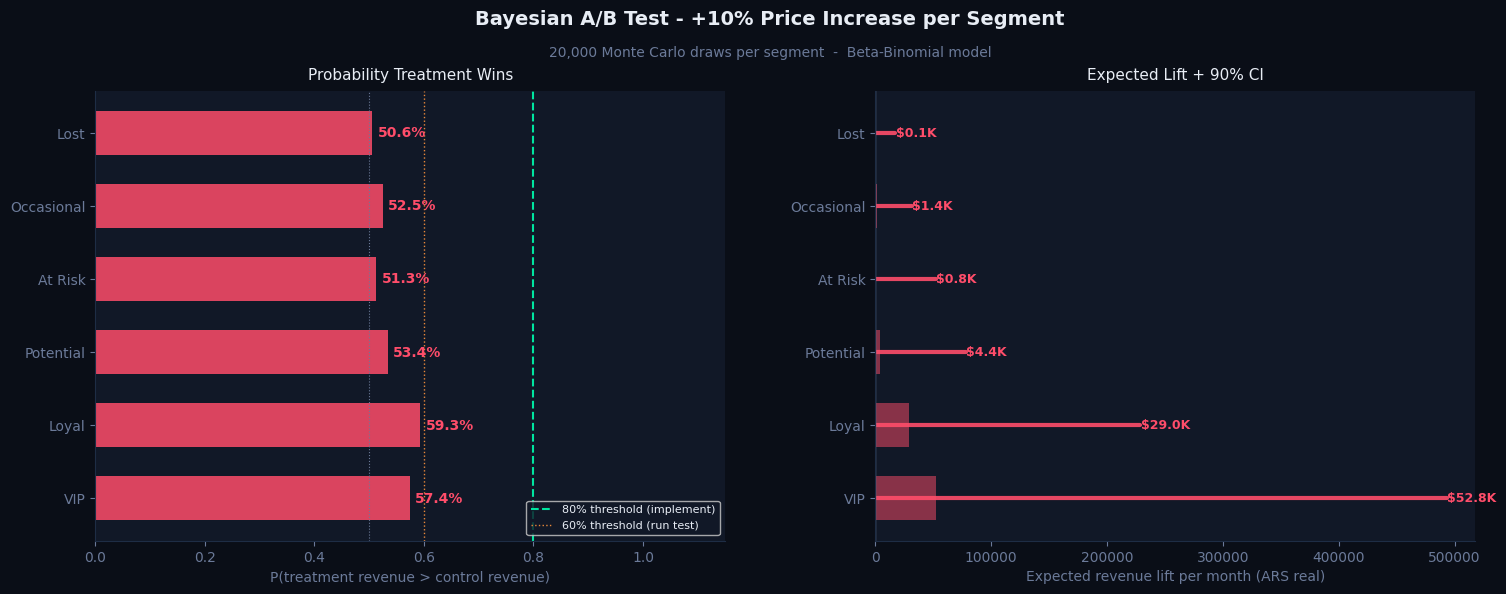

In [14]:
fig = plt.figure(figsize=(15, 9), facecolor=C['bg'])
fig.text(0.5, 0.97, f'Bayesian A/B Test - +{PRICE_INCREASE*100:.0f}% Price Increase per Segment',
         ha='center', va='top', fontsize=14, fontweight='bold', color=C['text'])
fig.text(0.5, 0.93, f'{N_SIM:,} Monte Carlo draws per segment  -  Beta-Binomial model',
         ha='center', va='top', fontsize=10, color=C['muted'])

ax1 = fig.add_axes([0.05, 0.38, 0.42, 0.50])
ax2 = fig.add_axes([0.57, 0.38, 0.40, 0.50])

seg_names = [r['segment'] for r in results]
p_wins = [r['p_win'] for r in results]
exp_lifts = [r['exp_lift']for r in results]
lift_lo = [r['lift_p5'] for r in results]
lift_hi = [r['lift_p95']for r in results]

bar_colors = [C['accent'] if p >= 0.80 else C['orange'] if p >= 0.60 else C['red'] for p in p_wins]

# P(win) bars
y = np.arange(len(seg_names))
bars = ax1.barh(y, p_wins, color=bar_colors, alpha=0.85, height=0.6)
ax1.axvline(0.80, color=C['accent'], linewidth=1.5, linestyle='--', label='80% threshold (implement)')
ax1.axvline(0.60, color=C['orange'], linewidth=1, linestyle=':', label='60% threshold (run test)')
ax1.axvline(0.50, color=C['muted'],  linewidth=0.8, linestyle=':')
for i, (bar, p) in enumerate(zip(bars, p_wins)):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{p:.1%}', va='center', fontsize=10, color=bar_colors[i], fontweight='bold')
ax1.set_yticks(y)
ax1.set_yticklabels(seg_names, fontsize=10)
ax1.set_xlabel('P(treatment revenue > control revenue)')
ax1.set_title('Probability Treatment Wins', fontsize=11, pad=8)
ax1.set_xlim(0, 1.15)
ax1.legend(fontsize=8, loc='lower right')
ax1.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax1.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax1.spines[sp].set_color(C['border'])

# Expected lift with CI
ax2.barh(y, [max(v,0) for v in exp_lifts], color=bar_colors, alpha=0.5, height=0.6)
for i in range(len(results)):
    ax2.plot([max(lift_lo[i],0), max(lift_hi[i],0)], [i,i],
             color=bar_colors[i], linewidth=3, alpha=0.9, solid_capstyle='round')
    ax2.text(max(lift_hi[i],0) + 500, i,
             f'${exp_lifts[i]/1e3:.1f}K', va='center', fontsize=9,
             color=bar_colors[i], fontweight='bold')
ax2.axvline(0, color=C['muted'], linewidth=1)
ax2.set_yticks(y)
ax2.set_yticklabels(seg_names, fontsize=10)
ax2.set_xlabel('Expected revenue lift per month (ARS real)')
ax2.set_title('Expected Lift + 90% CI', fontsize=11, pad=8)
ax2.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax2.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax2.spines[sp].set_color(C['border'])

plt.savefig(ROOT / 'plots' / '25_ab_results.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

## Revenue Distribution per Segment

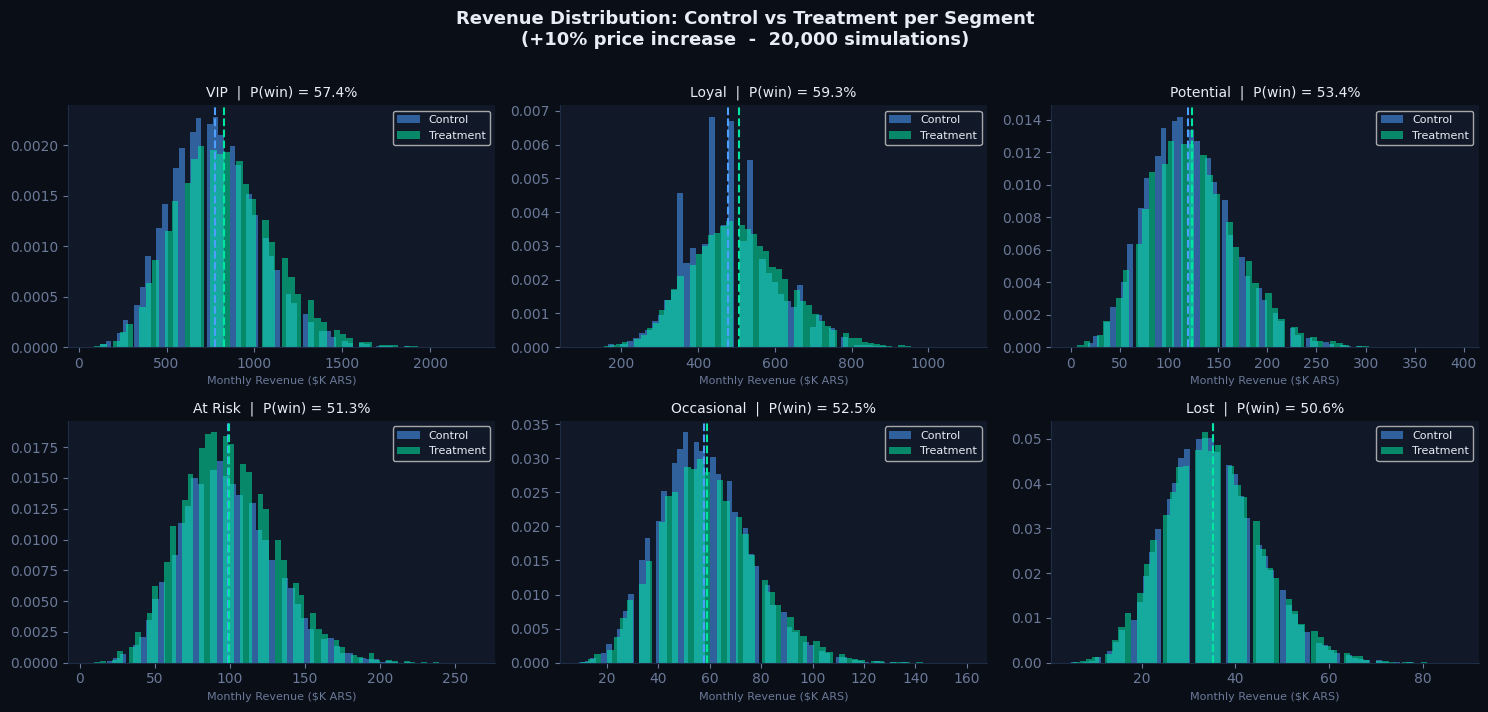

In [15]:
n_segs = len(results)
ncols = 3
nrows = (n_segs + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows*3.5), facecolor=C['bg'])
fig.suptitle('Revenue Distribution: Control vs Treatment per Segment\n'
             f'(+{PRICE_INCREASE*100:.0f}% price increase  -  {N_SIM:,} simulations)',
             fontsize=13, fontweight='bold', color=C['text'], y=1.01)

axes_flat = axes.flatten() if nrows > 1 else axes

for i, (r, ax) in enumerate(zip(results, axes_flat)):
    rev_ctrl = results[i]['rev_ctrl']
    rev_treat = results[i]['rev_treat']

    ax.hist(rev_ctrl / 1e3, bins=60, alpha=0.55, color=C['blue'], label='Control', density=True)
    ax.hist(rev_treat / 1e3, bins=60, alpha=0.55, color=C['accent'], label='Treatment', density=True)
    ax.axvline(rev_ctrl.mean() / 1e3, color=C['blue'], linewidth=1.5, linestyle='--')
    ax.axvline(rev_treat.mean() / 1e3, color=C['accent'], linewidth=1.5, linestyle='--')
    ax.set_title(f'{r["segment"]}  |  P(win) = {r["p_win"]:.1%}', fontsize=10, pad=6)
    ax.set_xlabel('Monthly Revenue ($K ARS)', fontsize=8)
    ax.legend(fontsize=8)
    ax.set_facecolor(C['surface'])
    for sp in ['top','right']:
        ax.spines[sp].set_visible(False)
    for sp in ['left','bottom']:
        ax.spines[sp].set_color(C['border'])

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(ROOT / 'plots' / '26_revenue_distributions.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

## Purchase Funnel by Segment

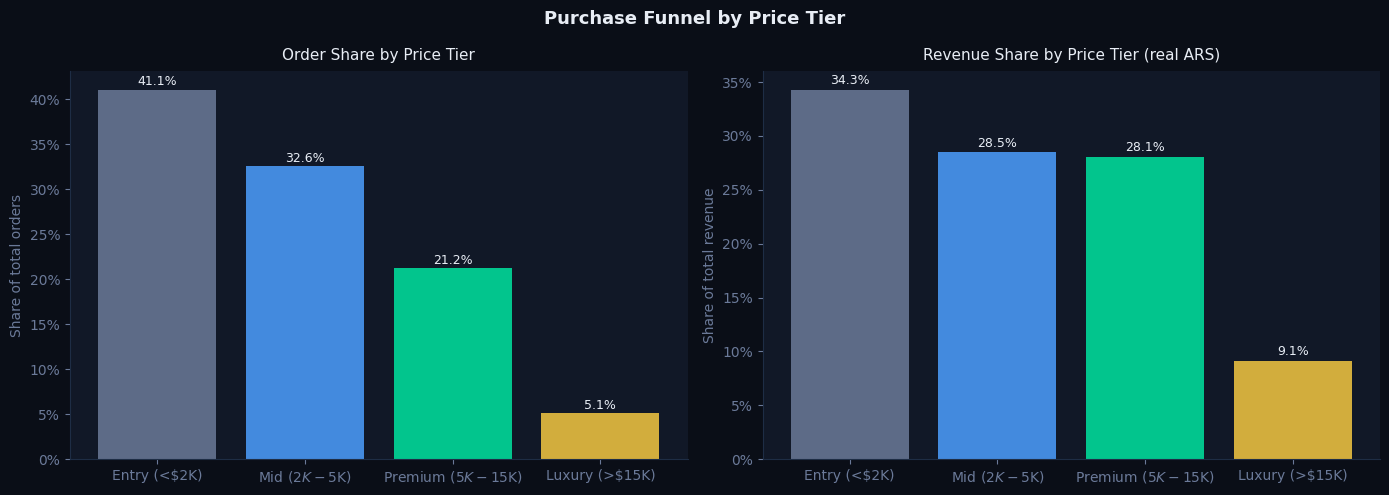

        price_tier  orders  order_share  revenue_share   avg_ticket
      Entry (<$2K)     145     0.410765       0.342999  1299.777241
     Mid ($2K-$5K)     115     0.325779       0.284915  3328.073043
Premium ($5K-$15K)      75     0.212465       0.280666  8586.408000
    Luxury (>$15K)      18     0.050992       0.091420 18371.111111


In [16]:
# Price tier segmentation
df['price_tier'] = pd.cut(
    df['unit_price'],
    bins=[0, 2000, 5000, 15000, np.inf],
    labels=['Entry (<$2K)', 'Mid ($2K-$5K)', 'Premium ($5K-$15K)', 'Luxury (>$15K)']
)

funnel = (
    df.groupby('price_tier', observed=True)
    .agg(
        orders = ('order_id', 'count'),
        revenue_real = ('gross_revenue_real','sum'),
        avg_ticket = ('unit_price', 'mean'),
    )
    .reset_index()
)
funnel['order_share'] = funnel['orders'] / funnel['orders'].sum()
funnel['revenue_share'] = funnel['revenue_real'] / funnel['revenue_real'].sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), facecolor=C['bg'])
fig.suptitle('Purchase Funnel by Price Tier', fontsize=13, fontweight='bold', color=C['text'])

tier_colors = [C['muted'], C['blue'], C['accent'], C['gold']]

bars = ax1.bar(funnel['price_tier'], funnel['order_share'],
               color=tier_colors, alpha=0.85)
ax1.set_title('Order Share by Price Tier', fontsize=11, pad=8)
ax1.set_ylabel('Share of total orders')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0%}'))
ax1.set_facecolor(C['surface'])
for bar, (_, row) in zip(bars, funnel.iterrows()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{row["order_share"]:.1%}', ha='center', fontsize=9)
for sp in ['top','right']:
    ax1.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax1.spines[sp].set_color(C['border'])

bars2 = ax2.bar(funnel['price_tier'], funnel['revenue_share'],
                color=tier_colors, alpha=0.85)
ax2.set_title('Revenue Share by Price Tier (real ARS)', fontsize=11, pad=8)
ax2.set_ylabel('Share of total revenue')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0%}'))
ax2.set_facecolor(C['surface'])
for bar, (_, row) in zip(bars2, funnel.iterrows()):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{row["revenue_share"]:.1%}', ha='center', fontsize=9)
for sp in ['top','right']:
    ax2.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax2.spines[sp].set_color(C['border'])

plt.tight_layout()
plt.savefig(ROOT / 'plots' / '27_funnel.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

print(funnel[['price_tier','orders','order_share','revenue_share','avg_ticket']].to_string(index=False))

## Sequential Testing

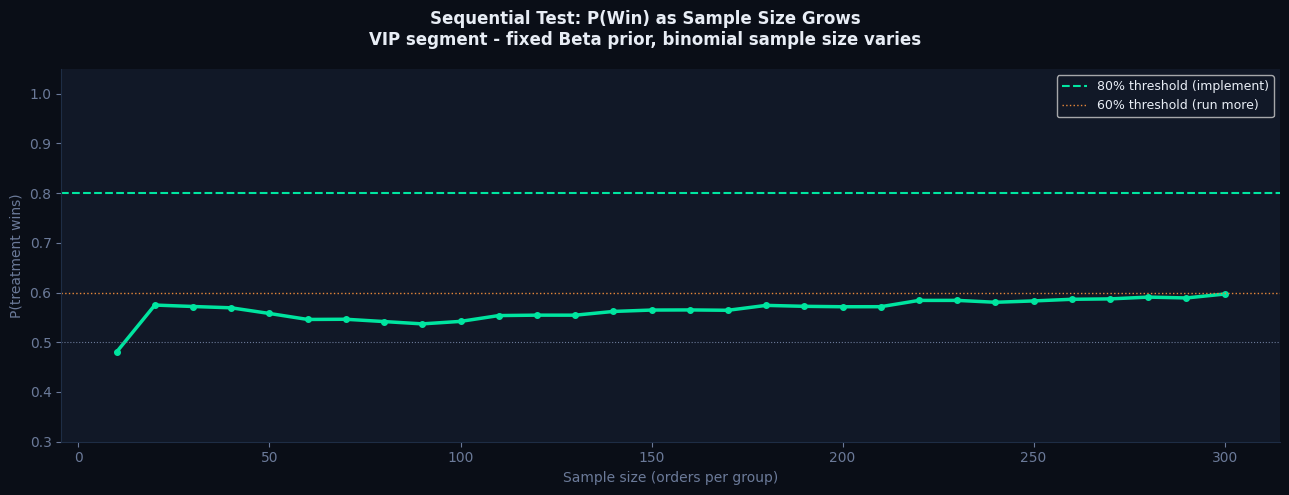

VIP segment does not reliably cross 80% within 300 orders per group
Recommendation: rely on aggregate elasticity result rather than segment-level A/B


In [17]:
# Sequential test: how does P(win) evolve as we collect more orders?
vip_idx = next(i for i, r in enumerate(results) if r['segment'] == 'VIP')
seg_row = seg_df[seg_df['segment'] == 'VIP'].iloc[0]

alpha_fixed = max(seg_row['n_skus'], 1)
beta_fixed = max(200 - seg_row['n_skus'], 1)

p_win_trajectory = []
n_range = range(10, 301, 10)

for n in n_range:
    p_ctrl = np.random.beta(alpha_fixed, beta_fixed, N_SIM)
    p_treat = np.clip(p_ctrl * (1 + PRICE_INCREASE) ** seg_row['elasticity'], 0, 1)
    o_ctrl = np.random.binomial(n, p_ctrl)
    o_treat = np.random.binomial(n, p_treat)
    rev_c = o_ctrl * seg_row['avg_ticket']
    rev_t = o_treat * seg_row['avg_ticket'] * (1 + PRICE_INCREASE)
    p_win_trajectory.append((rev_t > rev_c).mean())

fig, ax = plt.subplots(figsize=(13, 5), facecolor=C['bg'])
fig.suptitle('Sequential Test: P(Win) as Sample Size Grows\n'
             'VIP segment - fixed Beta prior, binomial sample size varies',
             fontsize=12, fontweight='bold', color=C['text'])

ax.plot(list(n_range), p_win_trajectory, color=C['accent'], linewidth=2.5, marker='o', markersize=4)
ax.axhline(0.80, color=C['accent'], linewidth=1.5, linestyle='--', label='80% threshold (implement)')
ax.axhline(0.60, color=C['orange'], linewidth=1,   linestyle=':', label='60% threshold (run more)')
ax.axhline(0.50, color=C['muted'], linewidth=0.8, linestyle=':')

cross_80 = next((n for n, p in zip(n_range, p_win_trajectory) if p >= 0.80), None)
if cross_80:
    ax.axvline(cross_80, color=C['gold'], linewidth=1.5, linestyle='--',
               label=f'Crosses 80% at n={cross_80}')

ax.set_xlabel('Sample size (orders per group)')
ax.set_ylabel('P(treatment wins)')
ax.set_ylim(0.3, 1.05)
ax.legend(fontsize=9)
ax.set_facecolor(C['surface'])
for sp in ['top','right']:
    ax.spines[sp].set_visible(False)
for sp in ['left','bottom']:
    ax.spines[sp].set_color(C['border'])

plt.tight_layout()
plt.savefig(ROOT / 'plots' / '28_sequential.png', dpi=150, bbox_inches='tight', facecolor=C['bg'])
plt.show()

if cross_80:
    print(f'VIP segment crosses 80% confidence at n={cross_80} orders per group')
    print(f'At current order rate, that is ~{cross_80 // max(int(monthly_orders), 1)} months of data')
else:
    print('VIP segment does not reliably cross 80% within 300 orders per group')
    print('Recommendation: rely on aggregate elasticity result rather than segment-level A/B')


## Decision Matrix

In [18]:
print('DECISION MATRIX - +10% PRICE INCREASE')
print()
print(f'{"Segment":<12} {"P(Win)":>8} {"E[Lift]/mo":>12} {"Verdict":<18} {"Recommended Action"}')
print()

actions = {
    'IMPLEMENT':'Raise price now for this segment',
    'RUN TEST': 'Gather 3 more months of data',
    'DO NOT IMPLEMENT': 'Hold price - risk outweighs expected gain',
}

for r in sorted(results, key=lambda x:
    x['p_win'], reverse=True):
    action = actions[r['verdict']]
    print(f'{r["segment"]:<12} {r["p_win"]:>7.1%} '
          f'${r["exp_lift"]:>10,.0f} '
          f'{r["verdict"]:<18} {action}')

print()
print('OVERALL RECOMMENDATION:')
overall_p_win = np.mean([r['p_win'] for r in results])
if overall_p_win >= 0.70:
    print(f'Implement +{PRICE_INCREASE*100:.0f}% across all segments (avg P(win) = {overall_p_win:.1%})')
elif overall_p_win >= 0.55:
    print(f'Implement for high-confidence segments only (avg P(win) = {overall_p_win:.1%})')
    print('Run longer test for remaining segments')
else:
    print(f'Defer price increase - data insufficient (avg P(win) = {overall_p_win:.1%})')
    print('Aggregate elasticity result supports increase but segment-level uncertainty is high')
    print('Consider a smaller increase (+5%) to reduce risk while gathering more data')

DECISION MATRIX - +10% PRICE INCREASE

Segment        P(Win)   E[Lift]/mo Verdict            Recommended Action

Loyal          59.3% $    28,978 DO NOT IMPLEMENT   Hold price - risk outweighs expected gain
VIP            57.4% $    52,838 DO NOT IMPLEMENT   Hold price - risk outweighs expected gain
Potential      53.4% $     4,418 DO NOT IMPLEMENT   Hold price - risk outweighs expected gain
Occasional     52.5% $     1,371 DO NOT IMPLEMENT   Hold price - risk outweighs expected gain
At Risk        51.3% $       832 DO NOT IMPLEMENT   Hold price - risk outweighs expected gain
Lost           50.6% $        77 DO NOT IMPLEMENT   Hold price - risk outweighs expected gain

OVERALL RECOMMENDATION:
Defer price increase - data insufficient (avg P(win) = 54.1%)
Aggregate elasticity result supports increase but segment-level uncertainty is high
Consider a smaller increase (+5%) to reduce risk while gathering more data


## Limitations & Caveats

**Model assumptions:**
- Segment-level elasticity multipliers are theory-based, not directly estimated
- Beta-Binomial assumes conversion rates are stationary, may not hold under inflation
- N_visitors = 200 per group is an assumption; real traffic data would change results

**Data limitations:**
- 350 total orders, underpowered for classical frequentist testing
- No competitor price data, cross-elasticity effects not captured
- No clickthrough/session data, conversion rate approximated from order counts

**What this analysis is good for:**
- Understanding the direction and shape of uncertainty
- Ranking segments by price sensitivity
- Estimating how much data a real A/B test would need

**What it should not be used for:**
- Precise revenue projections
- Replacing a real randomized experiment when one is feasible